Code created by: Lorena Espinosa, Johana Rátiva, Eduards Chipatecua 

Class: Procesamiento del Lenguaje Natural

University: Universidad de los Andes

Date: September 18, 2026

In [54]:
import re
import nltk
import pandas as pd

from nltk.corpus import stopwords
from sklearn.datasets import fetch_20newsgroups

nltk.download("stopwords")

stemmer = nltk.stem.SnowballStemmer("english")
english_stopwords = set(stopwords.words("english"))
from IPython.display import display

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import SGDClassifier

from sklearn.metrics import accuracy_score, classification_report

from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\adwar\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


# Clasificación temática: 20 Newsgroups


In [55]:
newsgroups = fetch_20newsgroups(
    subset="all",
    remove=("headers", "footers", "quotes"),
    random_state=0
)

print("Número de documentos:", len(newsgroups.data))
print("Número de clases:", len(newsgroups.target_names))

Número de documentos: 18846
Número de clases: 20


In [56]:
news_df = pd.DataFrame({
    "text": newsgroups.data,
    "label": newsgroups.target
})

news_df["label_name"] = news_df["label"].map(dict(enumerate(newsgroups.target_names)))

news_df.head()

,text,label,label_name
0,FOR SALE\n\n 1945 King Feature...,6,misc.forsale
1,Earlier today I read an ad for REAL-3D animati...,1,comp.graphics
2,Can someone cite Biblical references to homose...,15,soc.religion.christian
3,My friends and I have a buch of books for sale...,6,misc.forsale
4,\n\nThey are using some technology developed b...,11,sci.crypt


In [57]:
newsgroups.target_names

['alt.atheism',
 'comp.graphics',
 'comp.os.ms-windows.misc',
 'comp.sys.ibm.pc.hardware',
 'comp.sys.mac.hardware',
 'comp.windows.x',
 'misc.forsale',
 'rec.autos',
 'rec.motorcycles',
 'rec.sport.baseball',
 'rec.sport.hockey',
 'sci.crypt',
 'sci.electronics',
 'sci.med',
 'sci.space',
 'soc.religion.christian',
 'talk.politics.guns',
 'talk.politics.mideast',
 'talk.politics.misc',
 'talk.religion.misc']

In [58]:
news_df["label_name"].value_counts().sort_index()

label_name
alt.atheism                 799
comp.graphics               973
comp.os.ms-windows.misc     985
comp.sys.ibm.pc.hardware    982
comp.sys.mac.hardware       963
comp.windows.x              988
misc.forsale                975
rec.autos                   990
rec.motorcycles             996
rec.sport.baseball          994
rec.sport.hockey            999
sci.crypt                   991
sci.electronics             984
sci.med                     990
sci.space                   987
soc.religion.christian      997
talk.politics.guns          910
talk.politics.mideast       940
talk.politics.misc          775
talk.religion.misc          628
Name: count, dtype: int64

- Cantidad de documentos por clase.

## Procesamiento de texto

In [59]:
def preprocess(text):
    """Limpia y procesa un mensaje en inglés."""

    processed = re.sub(r"\W", " ", str(text))
    processed = re.sub(r"\s+[a-zA-Z]\s+", " ", processed)
    processed = re.sub(r"[0-9]+", " ", processed)
    processed = re.sub(r" +", " ", processed)
    processed = processed.lower()
    return " ".join(
        stemmer.stem(token)
        for token in processed.split()
        if token not in english_stopwords
    )

In [60]:
news_df["processed_text"] = [
    preprocess(text)
    for text in news_df["text"]
]

In [61]:
news_df.head()

,text,label,label_name,processed_text
0,FOR SALE\n\n 1945 King Feature...,6,misc.forsale,sale king featur syndic jaymar specialti compa...
1,Earlier today I read an ad for REAL-3D animati...,1,comp.graphics,earlier today read ad real anim ray trace soft...
2,Can someone cite Biblical references to homose...,15,soc.religion.christian,someon cite biblic refer homosexu immor leviti...
3,My friends and I have a buch of books for sale...,6,misc.forsale,friend buch book sale use due chang job loss i...
4,\n\nThey are using some technology developed b...,11,sci.crypt,use technolog develop vlsi system manufactur c...


### Visualización de los textos procesados

In [62]:
n_ejemplos = 5

ejemplos = (
    news_df[["text", "processed_text"]]
    .sample(n=n_ejemplos)
    .reset_index(drop=True)
    .copy()
)

ejemplos = ejemplos.rename(columns={
    "text": "Texto original",
    "processed_text": "Texto procesado"
})

display(
    ejemplos.style
    .set_properties(**{
        "white-space": "pre-wrap",
        "text-align": "left",
        "vertical-align": "top",
        "font-size": "14px",
        "padding": "12px"
    })
    .set_table_styles([
        {
            "selector": "table",
            "props": [
                ("width", "100%"),
                ("table-layout", "fixed")
            ]
        },
        {
            "selector": "th",
            "props": [
                ("text-align", "center"),
                ("font-size", "15px"),
                ("padding", "12px")
            ]
        }
    ])
)

,Texto original,Texto procesado
0,"But after you have taken antihistamines for a few nights, doesn't it start to have a paradoxical effect? I used to take one every night for allergies and couldn't figure out why I developed bad insomnia. Finally figured out it was the antihistamines. I would fall asleep for a few minutes but would awaken at the drop of a pin a little later and could not get back to sleep. I don't have that problem since I stopped the antihistamines at bedtime. ?",taken antihistamin night start paradox effect use take one everi night allergi figur develop bad insomnia final figur antihistamin would fall asleep minut would awaken drop pin littl later could get back sleep problem sinc stop antihistamin bedtim
1,"It clearly depends on the type of questions you are asking but in many cases it will do fine. The critical information from the neuron is in the firing frequency (maximum about 100 action potentials per seconds), and not in the amplitude of the signal or in details of the signal shape. So the resolution of about 0.4 % you get with an 8 bit convertor is more then sufficient. AC coupling does not have to be a problem either, since in many cases you are not interested in the DC level. My pre amplifier is AC coupled also. The critical point is the lowest frequency that will pass. If the cutoff point is to high, the action potentials will be slightly distorted. But even that normally does not matter since it is the occurrence of the spike that is important. However, I do want to know what exactly I can expect before I start battling with the toolbox to get it going. As yet I have no clue were to start looking for the technical specifications.",clear depend type question ask mani case fine critic inform neuron fire frequenc maximum action potenti per second amplitud signal detail signal shape resolut get bit convertor suffici ac coupl problem either sinc mani case interest dc level pre amplifi ac coupl also critic point lowest frequenc pass cutoff point high action potenti slight distort even normal matter sinc occurr spike import howev want know exact expect start battl toolbox get go yet clue start look technic specif
2,"Or, if you've got some entreprenuerial (sp?) spirit, get a cheapy clear plastic box, mount the simm inside, and sell it as a 'Pet SIMM'! I'm sure there are *plenty* of suckers out there who would go for it!",got entreprenueri sp spirit get cheapi clear plastic box mount simm insid sell pet simm sure plenti sucker would go
3,"I learned when riding bareback as a kid to ""palm-reign"", by just pushing on the right side of the horse's neck with your right palm to turn left - a lot like countersteering. So that came pretty easy to me in the transition to motorcycles. It took a while however to break my habit of kicking the rear fender with my heels to go faster.",learn ride bareback kid palm reign push right side hors neck right palm turn left lot like counterst came pretti easi transit motorcycl took howev break habit kick rear fender heel go faster
4,I have a 105MB IDE drive and am having a few problems! I get 'Data error on drive C' messages when reading some files. The problem is also steadily getting worse. I have run some diagnostic software (PCTools V7.1) and it says that the drive is OK - but it does have to retry some sectors and it briefly flashes up an error message (which is too quick to read). Does anybody know of any cheap or free software which could mark these sectors as bad (DOS doesn't) or preferably perform a low level format. I have heard that the latter is possible on an IDE. Technical answers would be appreciated. It would be nice to be able to use the disk again!!!,mb ide drive problem get data error drive messag read file problem also steadili get wors run diagnost softwar pctool v say drive ok retri sector briefli flash error messag quick read anybodi know cheap free softwar could mark sector bad dos prefer perform low level format heard latter possibl ide technic answer 

### Particiones 60% - 10% - 30%

In [63]:
train_df, temp_df = train_test_split(
    news_df,
    test_size=0.40,
    random_state=0,
    stratify=news_df["label"]
)

test_df, val_df = train_test_split(
    temp_df,
    test_size=0.25,
    random_state=0,
    stratify=temp_df["label"]
)

In [64]:
print("Total:", len(news_df))
print("Entrenamiento:", len(train_df))
print("Validación:", len(val_df))
print("Prueba:", len(test_df))

print("Entrenamiento:", len(train_df) / len(news_df))
print("Validación:", len(val_df) / len(news_df))
print("Prueba:", len(test_df) / len(news_df))

Total: 18846
Entrenamiento: 11307
Validación: 1885
Prueba: 5654
Entrenamiento: 0.5999681630054123
Validación: 0.10002122466305848
Prueba: 0.30001061233152926


In [65]:
distribucion = pd.DataFrame({
    "Entrenamiento": train_df["label_name"].value_counts(),
    "Validación": val_df["label_name"].value_counts(),
    "Prueba": test_df["label_name"].value_counts()
})

distribucion = distribucion.reindex(newsgroups.target_names)


In [66]:
distribucion.loc["TOTAL"] = distribucion.sum()

distribucion

,Entrenamiento,Validación,Prueba
label_name,,,
alt.atheism,479,80,240
comp.graphics,584,97,292
comp.os.ms-windows.misc,591,98,296
comp.sys.ibm.pc.hardware,589,98,295
comp.sys.mac.hardware,578,96,289
comp.windows.x,593,99,296
misc.forsale,585,97,293
rec.autos,594,99,297
rec.motorcycles,598,100,298


## Modelos y representaciones.

In [67]:
y_train = train_df["label_name"].to_numpy()
y_val = val_df["label_name"].to_numpy()
y_test = test_df["label_name"].to_numpy()

Función auxiliar para generar las gráficas de las métricas

In [68]:
def graficar_reporte_clasificacion(y_real, y_pred, titulo):
    """
    Grafica precision, recall y F1-score por clase y retorna
    el reporte completo de clasificación como un DataFrame.
    """
    reporte = classification_report(
        y_real,
        y_pred,
        digits=4,
        output_dict=True
    )

    df_reporte = pd.DataFrame(reporte).T

    df_clases = df_reporte.drop(
        index=["accuracy", "macro avg", "weighted avg"],
        errors="ignore"
    )

    nombres_cortos = [
        nombre[:12] + "..." if len(nombre) > 12 else nombre
        for nombre in df_clases.index
    ]

    ax = df_clases[
        ["precision", "recall", "f1-score"]
    ].plot(
        kind="bar",
        figsize=(16, 7),
        width=0.8
    )

    ax.set_title(titulo)
    ax.set_xlabel("Clase")
    ax.set_ylabel("Puntuación")
    ax.set_ylim(0, 1)

    ax.set_xticklabels(
        nombres_cortos,
        rotation=45,
        ha="right",
        fontsize=9
    )

    ax.legend(
        title="Métrica",
        bbox_to_anchor=(1.02, 1),
        loc="upper left"
    )

    plt.tight_layout()
    plt.show()

    return df_reporte

### CountVectorizer

In [69]:
count_vectorizer = CountVectorizer(
    max_features=2500
)

X_train_count = count_vectorizer.fit_transform(
    train_df["processed_text"]
)

X_val_count = count_vectorizer.transform(
    val_df["processed_text"]
)

print("Train:", X_train_count.shape)
print("Validación:", X_val_count.shape)

Train: (11307, 2500)
Validación: (1885, 2500)


### TF-IDF

In [70]:
tfidf_vectorizer = TfidfVectorizer(
    max_features=2500
)

X_train_tfidf = tfidf_vectorizer.fit_transform(
    train_df["processed_text"]
)

X_val_tfidf = tfidf_vectorizer.transform(
    val_df["processed_text"]
)

print("Train:", X_train_tfidf.shape)
print("Validación:", X_val_tfidf.shape)

Train: (11307, 2500)
Validación: (1885, 2500)


### CountVectorizer + Naive Bayes

In [71]:
nb_count = MultinomialNB()

nb_count.fit(
    X_train_count,
    y_train
)

pred_nb_count = nb_count.predict(
    X_val_count
)

acc_nb_count = accuracy_score(
    y_val,
    pred_nb_count
)

print("Accuracy:", acc_nb_count)

Accuracy: 0.6249336870026525


In [72]:
reporte = classification_report(
    y_val,
    pred_nb_count,
    digits=4,
    output_dict=True
)

df_reporte = pd.DataFrame(reporte).T

df_reporte = df_reporte.rename(
    columns={
        "support": "n_validacion"
    }
)
df_reporte["n_validacion"] = (
    df_reporte["n_validacion"]
    .round()
    .astype(int)
)
df_reporte

,precision,recall,f1-score,n_validacion
alt.atheism,0.464646,0.575000,0.513966,80
comp.graphics,0.568627,0.597938,0.582915,97
comp.os.ms-windows.misc,0.666667,0.020408,0.039604,98
comp.sys.ibm.pc.hardware,0.476562,0.622449,0.539823,98
comp.sys.mac.hardware,0.582677,0.770833,0.663677,96
comp.windows.x,0.568182,0.757576,0.649351,99
misc.forsale,0.845238,0.731959,0.784530,97
rec.autos,0.627451,0.646465,0.636816,99
rec.motorcycles,0.616822,0.660000,0.637681,100
rec.sport.baseball,0.712963,0.770000,0.740385,100


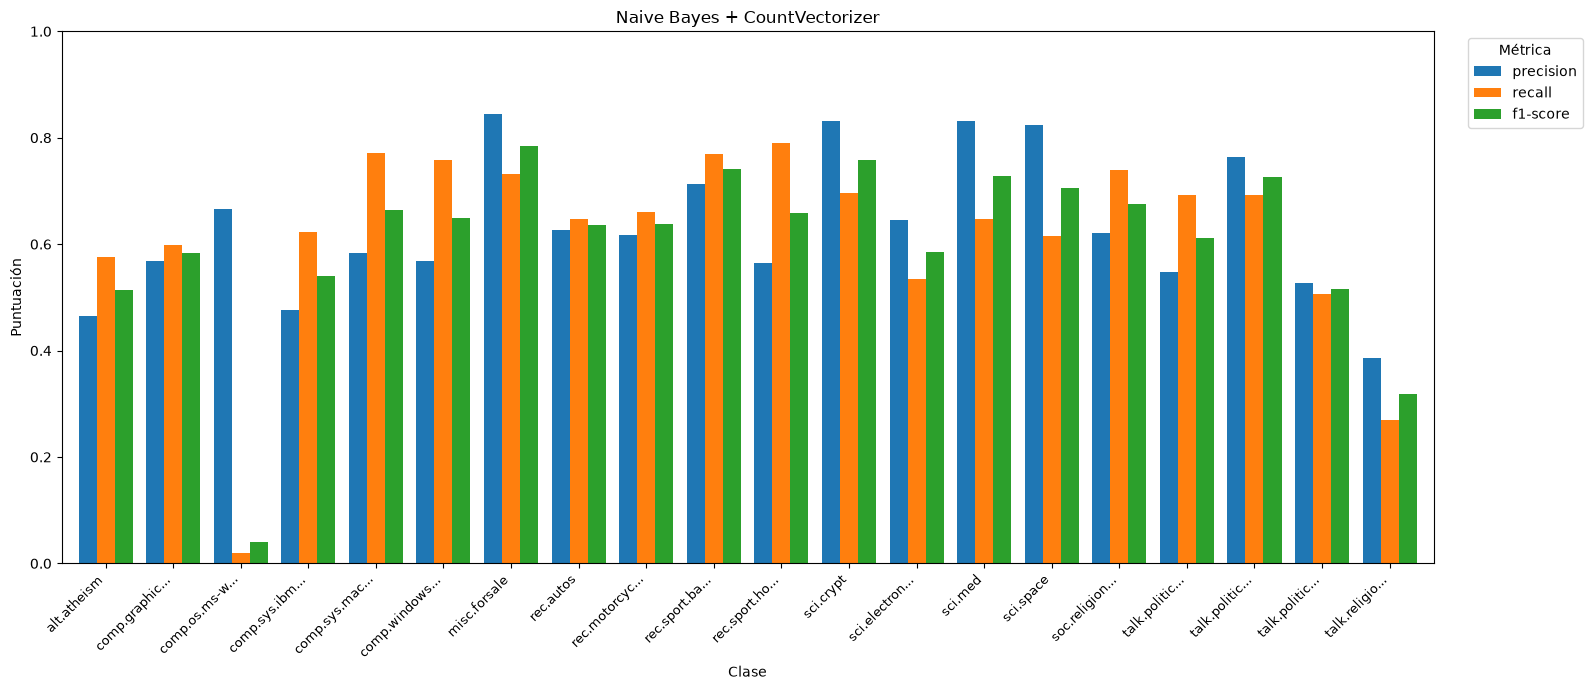

In [73]:
df_reporte_nb_count = graficar_reporte_clasificacion(
    y_val,
    pred_nb_count,
    "Naive Bayes + CountVectorizer"
)

### CountVectorizer + regresión logística

In [74]:
lr_count = LogisticRegression(
    C=1.0,
    max_iter=1000,
    random_state=0
)

lr_count.fit(X_train_count, y_train)

pred_lr_count = lr_count.predict(X_val_count)

acc_lr_count = accuracy_score(y_val, pred_lr_count)

print("Accuracy:", acc_lr_count)

Accuracy: 0.593103448275862


In [75]:
print(
    classification_report(
        y_val,
        pred_lr_count,
        digits=4
    )
)

                          precision    recall  f1-score   support

             alt.atheism     0.4507    0.4000    0.4238        80
           comp.graphics     0.5729    0.5670    0.5699        97
 comp.os.ms-windows.misc     0.5052    0.5000    0.5026        98
comp.sys.ibm.pc.hardware     0.5556    0.5612    0.5584        98
   comp.sys.mac.hardware     0.6207    0.5625    0.5902        96
          comp.windows.x     0.6500    0.6566    0.6533        99
            misc.forsale     0.7396    0.7320    0.7358        97
               rec.autos     0.5922    0.6162    0.6040        99
         rec.motorcycles     0.5842    0.5900    0.5871       100
      rec.sport.baseball     0.4783    0.7700    0.5900       100
        rec.sport.hockey     0.8506    0.7400    0.7914       100
               sci.crypt     0.6778    0.6162    0.6455        99
         sci.electronics     0.5000    0.4646    0.4817        99
                 sci.med     0.7065    0.6566    0.6806        99
         

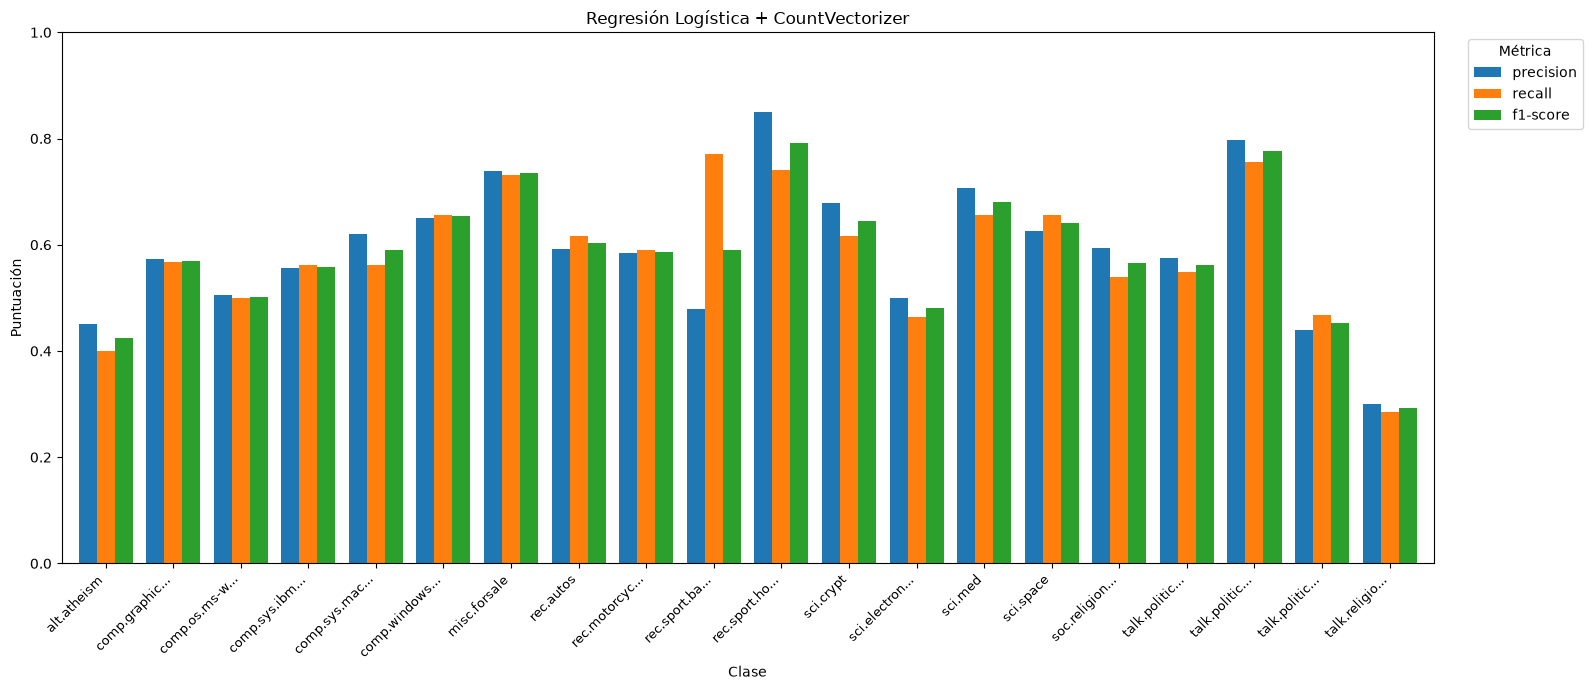

In [76]:
df_reporte_lr_count = graficar_reporte_clasificacion(
    y_val,
    pred_lr_count,
    "Regresión Logística + CountVectorizer"
)

## TF-IDF + Naive Bayes

In [77]:
nb_tfidf = MultinomialNB()

nb_tfidf.fit(
    X_train_tfidf,
    y_train
)

pred_nb_tfidf = nb_tfidf.predict(
    X_val_tfidf
)

acc_nb_tfidf = accuracy_score(
    y_val,
    pred_nb_tfidf
)

print("Accuracy:", acc_nb_tfidf)

Accuracy: 0.6641909814323608


In [78]:
print(
    classification_report(
        y_val,
        pred_nb_tfidf,
        digits=4
    )
)

                          precision    recall  f1-score   support

             alt.atheism     0.5593    0.4125    0.4748        80
           comp.graphics     0.5648    0.6289    0.5951        97
 comp.os.ms-windows.misc     0.6211    0.6020    0.6114        98
comp.sys.ibm.pc.hardware     0.6126    0.6939    0.6507        98
   comp.sys.mac.hardware     0.6923    0.6562    0.6738        96
          comp.windows.x     0.6909    0.7677    0.7273        99
            misc.forsale     0.8605    0.7629    0.8087        97
               rec.autos     0.6737    0.6465    0.6598        99
         rec.motorcycles     0.7033    0.6400    0.6702       100
      rec.sport.baseball     0.8041    0.7800    0.7919       100
        rec.sport.hockey     0.5548    0.8600    0.6745       100
               sci.crypt     0.7527    0.7071    0.7292        99
         sci.electronics     0.6456    0.5152    0.5730        99
                 sci.med     0.7727    0.6869    0.7273        99
         

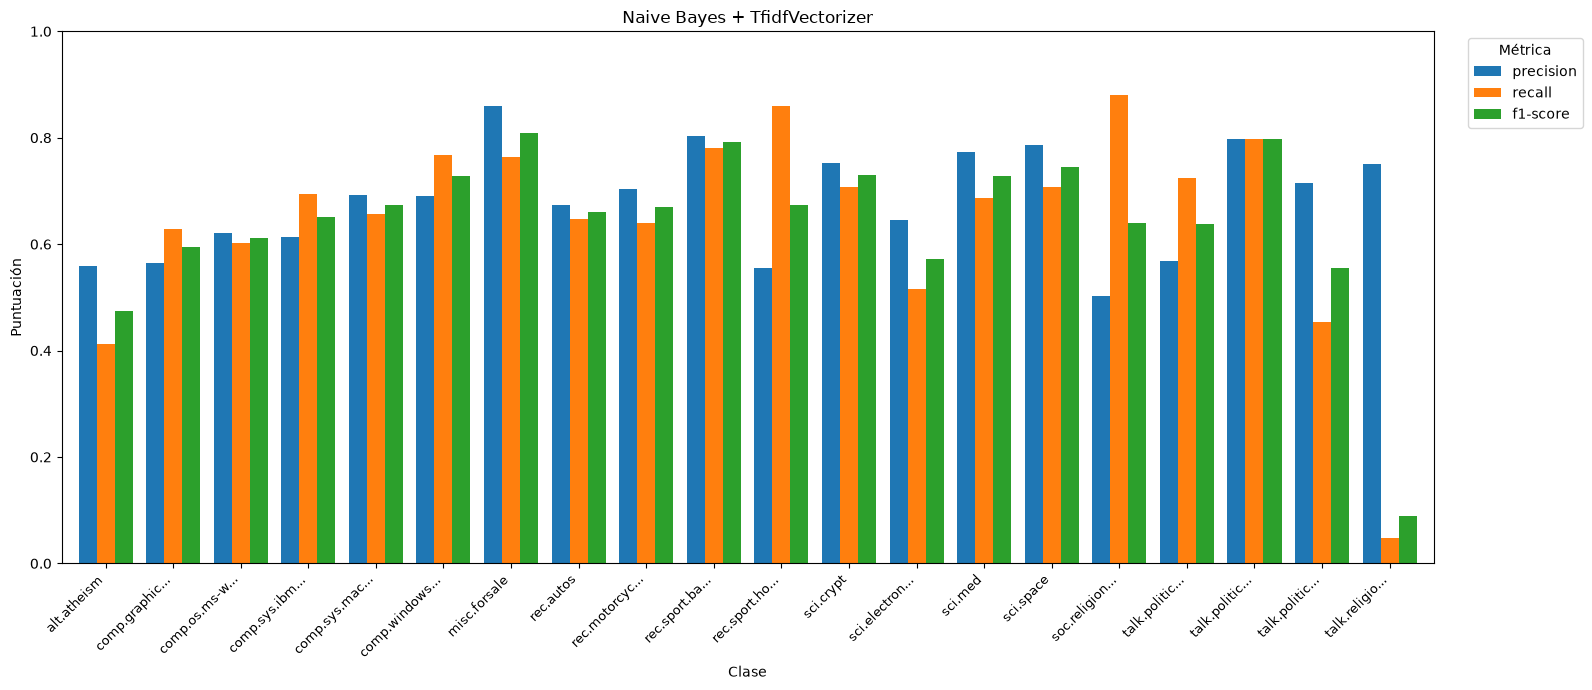

In [79]:
df_reporte_nb_tfidf = graficar_reporte_clasificacion(
    y_val,
    pred_nb_tfidf,
    "Naive Bayes + TfidfVectorizer"
)

### TF-IDF + regresión logística

In [80]:
lr_tfidf = LogisticRegression(
    C=1.0,
    max_iter=1000,
    random_state=0
)

lr_tfidf.fit(X_train_tfidf, y_train)

pred_lr_tfidf = lr_tfidf.predict(X_val_tfidf)

acc_lr_tfidf = accuracy_score(y_val, pred_lr_tfidf)

print("Accuracy:", acc_lr_tfidf)

Accuracy: 0.6551724137931034


In [81]:
print(
    classification_report(
        y_val,
        pred_lr_tfidf,
        digits=4
    )
)

                          precision    recall  f1-score   support

             alt.atheism     0.5211    0.4625    0.4901        80
           comp.graphics     0.5769    0.6186    0.5970        97
 comp.os.ms-windows.misc     0.6154    0.5714    0.5926        98
comp.sys.ibm.pc.hardware     0.6429    0.6429    0.6429        98
   comp.sys.mac.hardware     0.6559    0.6354    0.6455        96
          comp.windows.x     0.7158    0.6869    0.7010        99
            misc.forsale     0.7789    0.7629    0.7708        97
               rec.autos     0.4467    0.6768    0.5382        99
         rec.motorcycles     0.6667    0.6200    0.6425       100
      rec.sport.baseball     0.8105    0.7700    0.7897       100
        rec.sport.hockey     0.8667    0.7800    0.8211       100
               sci.crypt     0.7816    0.6869    0.7312        99
         sci.electronics     0.5510    0.5455    0.5482        99
                 sci.med     0.7273    0.7273    0.7273        99
         

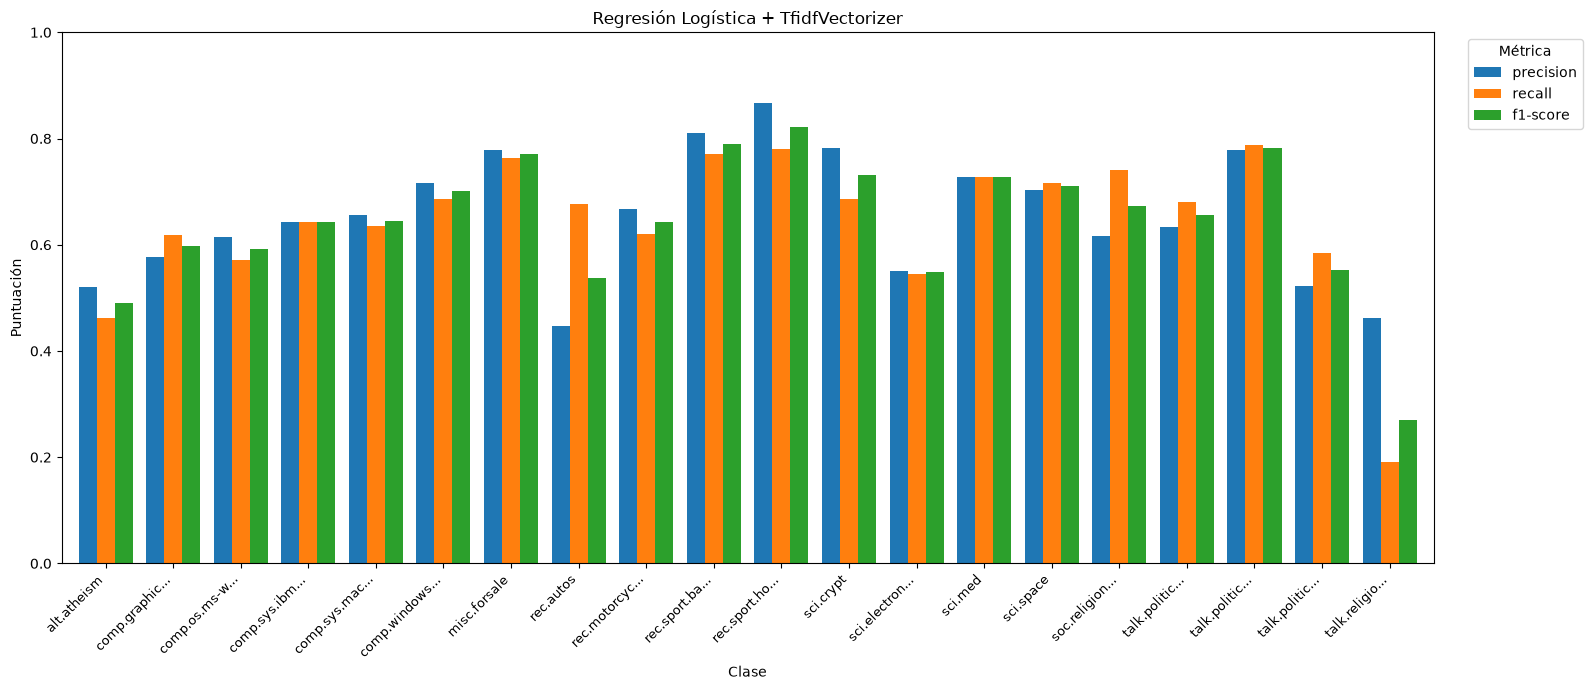

In [82]:
df_reporte_lr_tfidf = graficar_reporte_clasificacion(
    y_val,
    pred_lr_tfidf,
    "Regresión Logística + TfidfVectorizer"
)

### Comparación de los 4 modelos

In [83]:
resultados = pd.DataFrame({
    "Representación": [
        "CountVectorizer",
        "CountVectorizer",
        "TF-IDF",
        "TF-IDF"
    ],
    "Modelo": [
        "Naive Bayes",
        "Regresión logística",
        "Naive Bayes",
        "Regresión logística"
    ],
    "Accuracy_validacion": [
        acc_nb_count,
        acc_lr_count,
        acc_nb_tfidf,
        acc_lr_tfidf
    ]
})

resultados = resultados.sort_values(
    "Accuracy_validacion",
    ascending=False
).reset_index(drop=True)

resultados

,Representación,Modelo,Accuracy_validacion
0,TF-IDF,Naive Bayes,0.664191
1,TF-IDF,Regresión logística,0.655172
2,CountVectorizer,Naive Bayes,0.624934
3,CountVectorizer,Regresión logística,0.593103


In [84]:
def evaluar_modelo(nombre,modelo,X_train,X_val,y_train,y_val):
    """
    Evalúa el accuracy del modelo en entrenamiento y validación,
    retornando los resultados junto con el nombre de la configuración.
    """
    pred_train = modelo.predict(X_train)
    pred_val = modelo.predict(X_val)

    return {
        "Configuración": nombre,
        "Accuracy_train": accuracy_score(
            y_train,
            pred_train
        ),
        "Accuracy_validacion": accuracy_score(
            y_val,
            pred_val
        )
    }

In [85]:
resultados = [
    evaluar_modelo(
        "Count + Naive Bayes",
        nb_count,
        X_train_count,
        X_val_count,
        y_train,
        y_val
    ),

    evaluar_modelo(
        "Count + Regresión logística",
        lr_count,
        X_train_count,
        X_val_count,
        y_train,
        y_val
    ),

    evaluar_modelo(
        "TF-IDF + Naive Bayes",
        nb_tfidf,
        X_train_tfidf,
        X_val_tfidf,
        y_train,
        y_val
    ),

    evaluar_modelo(
        "TF-IDF + Regresión logística",
        lr_tfidf,
        X_train_tfidf,
        X_val_tfidf,
        y_train,
        y_val
    )
]

resultados_df = pd.DataFrame(resultados)

resultados_df = resultados_df.sort_values(
    "Accuracy_validacion",
    ascending=False
)

resultados_df

,Configuración,Accuracy_train,Accuracy_validacion
2,TF-IDF + Naive Bayes,0.768550,0.664191
3,TF-IDF + Regresión logística,0.824003,0.655172
0,Count + Naive Bayes,0.699036,0.624934
1,Count + Regresión logística,0.952596,0.593103


### Selección de hiperparámetros

In [86]:
train_val_df = pd.concat([train_df, val_df], ignore_index=True)

X_train_val = train_val_df["processed_text"]
y_train_val = train_val_df["label_name"]

print("Documentos para validación cruzada:", len(X_train_val))
print("Documentos de prueba:", len(test_df))

Documentos para validación cruzada: 13192
Documentos de prueba: 5654


In [87]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=0
)

In [88]:
valores_alpha = [0.1, 1.0, 10.0]
valores_C = [0.1, 1.0, 10.0]

In [89]:
pipelines = {
    "Count + Naive Bayes": Pipeline([
        ("vectorizador", CountVectorizer(max_features=2500)),
        ("clasificador", MultinomialNB())
    ]),

    "Count + Regresión logística": Pipeline([
        ("vectorizador", CountVectorizer(max_features=2500)),
        ("clasificador", LogisticRegression(max_iter=1000, random_state=0))
    ]),

    "TF-IDF + Naive Bayes": Pipeline([
        ("vectorizador", TfidfVectorizer(max_features=2500)),
        ("clasificador", MultinomialNB())
    ]),

    "TF-IDF + Regresión logística": Pipeline([
        ("vectorizador", TfidfVectorizer(max_features=2500)),
        ("clasificador", LogisticRegression(max_iter=1000, random_state=0))
    ])
}

In [90]:
busquedas = {}
mejores_modelos = {}

for nombre, pipeline in pipelines.items():

    if isinstance(pipeline.named_steps["clasificador"], MultinomialNB):
        param_grid = {"clasificador__alpha": valores_alpha}
    else:
        param_grid = {"clasificador__C": valores_C}

    busqueda = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        scoring="f1_macro",
        cv=cv,
        n_jobs=1,
        refit=True
    )

    # Ejecutar la validación cruzada
    busqueda.fit(X_train_val, y_train_val)

    # Guardar los resultados
    busquedas[nombre] = busqueda
    mejores_modelos[nombre] = busqueda.best_estimator_

    print(f"\nModelo: {nombre}")
    print("Mejores hiperparámetros:", busqueda.best_params_)
    print("F1 macro promedio:", round(busqueda.best_score_, 4))


Modelo: Count + Naive Bayes
Mejores hiperparámetros: {'clasificador__alpha': 1.0}
F1 macro promedio: 0.605

Modelo: Count + Regresión logística
Mejores hiperparámetros: {'clasificador__C': 0.1}
F1 macro promedio: 0.6358

Modelo: TF-IDF + Naive Bayes
Mejores hiperparámetros: {'clasificador__alpha': 0.1}
F1 macro promedio: 0.6622

Modelo: TF-IDF + Regresión logística
Mejores hiperparámetros: {'clasificador__C': 1.0}
F1 macro promedio: 0.6621


In [91]:
resultados_hiperparametros = []

for nombre, busqueda in busquedas.items():

    resultados_cv = busqueda.cv_results_

    for i, parametros in enumerate(resultados_cv["params"]):

        resultados_hiperparametros.append({
            "Modelo": nombre,
            "Hiperparámetro": list(parametros.keys())[0].split("__")[-1],
            "Valor": list(parametros.values())[0],
            "F1_macro_promedio": resultados_cv["mean_test_score"][i],
            "Desviación_estándar": resultados_cv["std_test_score"][i]
        })

df_hiperparametros = pd.DataFrame(resultados_hiperparametros)

df_hiperparametros = df_hiperparametros.sort_values(
    ["Modelo", "F1_macro_promedio"],
    ascending=[True, False]
).reset_index(drop=True)

display(df_hiperparametros)

,Modelo,Hiperparámetro,Valor,F1_macro_promedio,Desviación_estándar
0,Count + Naive Bayes,alpha,1.0,0.605006,0.004981
1,Count + Naive Bayes,alpha,0.1,0.604640,0.004263
2,Count + Naive Bayes,alpha,10.0,0.584741,0.005260
3,Count + Regresión logística,C,0.1,0.635762,0.009118
4,Count + Regresión logística,C,1.0,0.606059,0.010100
5,Count + Regresión logística,C,10.0,0.570254,0.009377
6,TF-IDF + Naive Bayes,alpha,0.1,0.662154,0.004689
7,TF-IDF + Naive Bayes,alpha,1.0,0.649080,0.005218
8,TF-IDF + Naive Bayes,alpha,10.0,0.590335,0.005185
9,TF-IDF + Regresión logística,C,1.0,0.662148,0.004927


In [92]:
resumen_hiperparametros = []

for nombre, busqueda in busquedas.items():

    resumen_hiperparametros.append({
        "Modelo": nombre,
        "Mejor_hiperparametro": busqueda.best_params_,
        "F1_macro_CV": busqueda.best_score_
    })

df_resumen_hiperparametros = pd.DataFrame(resumen_hiperparametros)

df_resumen_hiperparametros = df_resumen_hiperparametros.sort_values(
    "F1_macro_CV",
    ascending=False
).reset_index(drop=True)

display(df_resumen_hiperparametros)

,Modelo,Mejor_hiperparametro,F1_macro_CV
0,TF-IDF + Naive Bayes,{'clasificador__alpha': 0.1},0.662154
1,TF-IDF + Regresión logística,{'clasificador__C': 1.0},0.662148
2,Count + Regresión logística,{'clasificador__C': 0.1},0.635762
3,Count + Naive Bayes,{'clasificador__alpha': 1.0},0.605006


### Análisis de la selección de hiperparámetros

Se evaluaron tres valores de α para Multinomial Naive Bayes (0.1, 1.0 y 10.0) y tres valores de C para regresión logística (0.1, 1.0 y 10.0), utilizando validación cruzada estratificada de cinco particiones y F1 macro como criterio de selección.

Para CountVectorizer + Naive Bayes se seleccionó α = 1.0, con un F1 macro promedio de 0.605006. En CountVectorizer + regresión logística se seleccionó C = 0.1, con un F1 macro promedio de 0.635762.

Por otra parte, TF-IDF + Naive Bayes obtuvo su mayor F1 macro promedio con α = 0.1, alcanzando 0.662154, mientras que TF-IDF + regresión logística obtuvo 0.662148 con C = 1.0.

Los resultados muestran que las combinaciones basadas en TF-IDF obtuvieron un mayor F1 macro promedio que sus equivalentes basadas en CountVectorizer. Asimismo, los hiperparámetros seleccionados variaron según el vectorizador utilizado, lo que evidencia la importancia de ajustar conjuntamente la representación textual y el clasificador.

Las dos configuraciones basadas en TF-IDF obtuvieron resultados prácticamente idénticos, con una diferencia de 0.000006 en su F1 macro promedio. Por tanto, no se puede establecer una superioridad concluyente entre ambas a partir de esta diferencia.

Se seleccionó el mejor hiperparámetro para cada una de las cuatro combinaciones.


In [93]:
modelo_nb_count = mejores_modelos["Count + Naive Bayes"]

modelo_nb_count

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('vectorizador', ...), ('clasificador', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[<U24](20,)","['alt.atheism','comp.graphics','comp.os.ms-windows.misc',..., 'talk.politics.mideast','talk.politics.misc','talk.religion.misc']"
,"max_features max_features: int, default=NoneIf not None, build a vocabulary that only consider the top`max_features` ordered by term frequency across the corpus.Otherwise, all features are used.This parameter is ignored if vocabulary is not None.",2500
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None


###  Evaluación final

In [ ]:
X_test = test_df["processed_text"]
y_test = test_df["label_name"]

resultados_finales = []
predicciones_finales = {}

for nombre, modelo in mejores_modelos.items():

    y_pred = modelo.predict(X_test)

    predicciones_finales[nombre] = y_pred

    resultados_finales.append({
        "Modelo": nombre,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision_macro": precision_score(y_test, y_pred, average="macro", zero_division=0),
        "Precision_micro": precision_score(y_test, y_pred, average="micro", zero_division=0),
        "Recall_macro": recall_score(y_test, y_pred, average="macro", zero_division=0),
        "Recall_micro": recall_score(y_test, y_pred, average="micro", zero_division=0),
        "F1_macro": f1_score(y_test, y_pred, average="macro", zero_division=0),
        "F1_micro": f1_score(y_test, y_pred, average="micro", zero_division=0)
    })

df_resultados_finales = pd.DataFrame(resultados_finales)

display(df_resultados_finales)

,Modelo,Accuracy,Precision_macro,Precision_micro,Recall_macro,Recall_micro,F1_macro,F1_micro
0,Count + Naive Bayes,0.618146,0.625029,0.618146,0.608301,0.618146,0.596113,0.618146
1,Count + Regresión logística,0.641139,0.652463,0.641139,0.630894,0.641139,0.635921,0.641139
2,TF-IDF + Naive Bayes,0.670145,0.667406,0.670145,0.657350,0.670145,0.655331,0.670145
3,TF-IDF + Regresión logística,0.669084,0.668415,0.669084,0.656641,0.669084,0.657911,0.669084


### Tabla comparativa de los resultados

In [96]:
df_resultados_finales = df_resultados_finales.sort_values(
    "F1_macro",
    ascending=False
).reset_index(drop=True)

display(
    df_resultados_finales.style.format({
        "Accuracy": "{:.4f}",
        "Precision_macro": "{:.4f}",
        "Precision_micro": "{:.4f}",
        "Recall_macro": "{:.4f}",
        "Recall_micro": "{:.4f}",
        "F1_macro": "{:.4f}",
        "F1_micro": "{:.4f}"
    })
)

,Modelo,Accuracy,Precision_macro,Precision_micro,Recall_macro,Recall_micro,F1_macro,F1_micro
0,TF-IDF + Regresión logística,0.6691,0.6684,0.6691,0.6566,0.6691,0.6579,0.6691
1,TF-IDF + Naive Bayes,0.6701,0.6674,0.6701,0.6574,0.6701,0.6553,0.6701
2,Count + Regresión logística,0.6411,0.6525,0.6411,0.6309,0.6411,0.6359,0.6411
3,Count + Naive Bayes,0.6181,0.6250,0.6181,0.6083,0.6181,0.5961,0.6181


In [97]:
nombre_mejor_modelo = max(
    busquedas,
    key=lambda nombre: busquedas[nombre].best_score_
)

mejor_modelo = mejores_modelos[nombre_mejor_modelo]
y_pred_mejor = predicciones_finales[nombre_mejor_modelo]

print("Mejor modelo:", nombre_mejor_modelo)
print("Hiperparámetros:", busquedas[nombre_mejor_modelo].best_params_)
print("F1 macro CV:", busquedas[nombre_mejor_modelo].best_score_)
print("F1 macro prueba:", f1_score(y_test, y_pred_mejor, average="macro"))

Mejor modelo: TF-IDF + Naive Bayes
Hiperparámetros: {'clasificador__alpha': 0.1}
F1 macro CV: 0.6621539989916482
F1 macro prueba: 0.6553312854841851


### Matriz de confusión

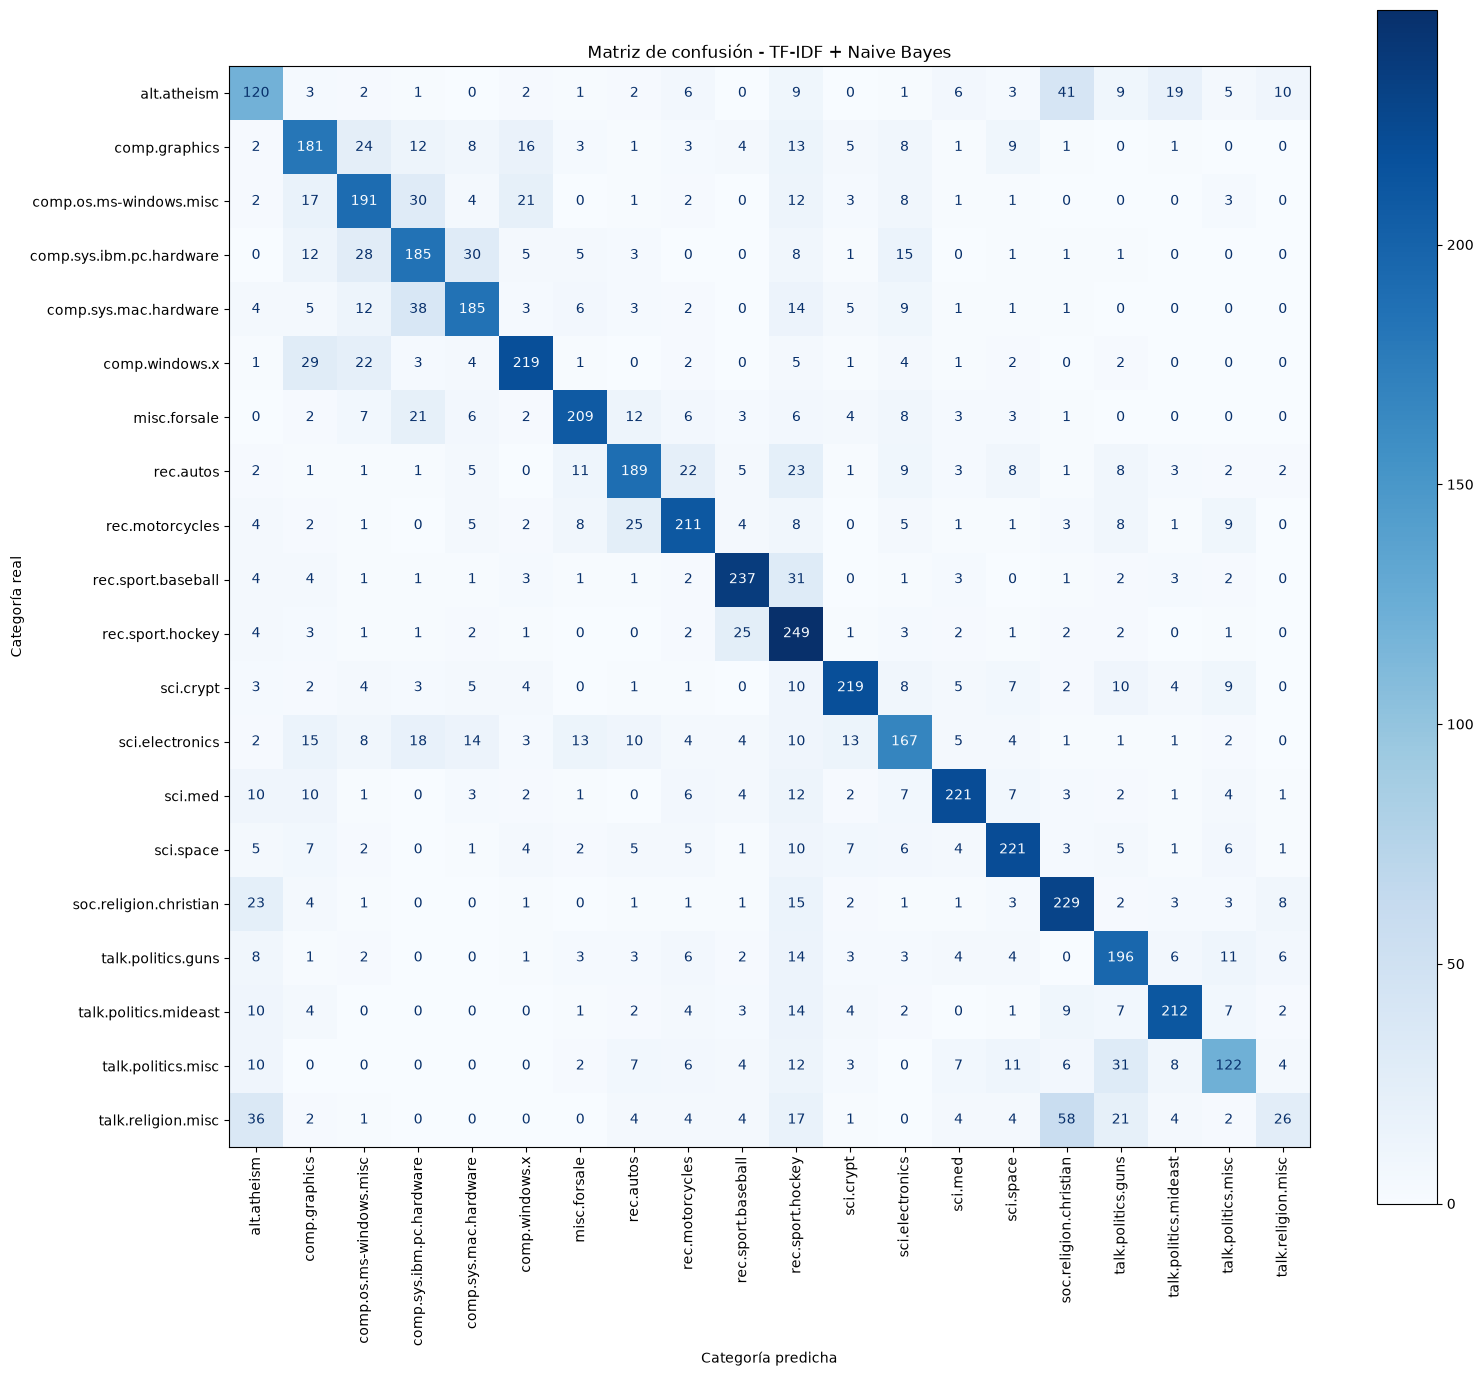

In [98]:

clases = mejor_modelo.named_steps["clasificador"].classes_

matriz_confusion = confusion_matrix(
    y_test,
    y_pred_mejor,
    labels=clases
)

fig, ax = plt.subplots(figsize=(16, 14))

disp = ConfusionMatrixDisplay(
    confusion_matrix=matriz_confusion,
    display_labels=clases
)

disp.plot(
    ax=ax,
    cmap="Blues",
    xticks_rotation=90,
    values_format="d",
    colorbar=True
)

ax.set_title(f"Matriz de confusión - {nombre_mejor_modelo}")
ax.set_xlabel("Categoría predicha")
ax.set_ylabel("Categoría real")

plt.tight_layout()
plt.show()

In [99]:
print(
    classification_report(
        y_test,
        y_pred_mejor,
        labels=clases,
        digits=4,
        zero_division=0
    )
)

                          precision    recall  f1-score   support

             alt.atheism     0.4800    0.5000    0.4898       240
           comp.graphics     0.5954    0.6199    0.6074       292
 comp.os.ms-windows.misc     0.6181    0.6453    0.6314       296
comp.sys.ibm.pc.hardware     0.5892    0.6271    0.6076       295
   comp.sys.mac.hardware     0.6777    0.6401    0.6584       289
          comp.windows.x     0.7578    0.7399    0.7487       296
            misc.forsale     0.7828    0.7133    0.7464       293
               rec.autos     0.7000    0.6364    0.6667       297
         rec.motorcycles     0.7153    0.7081    0.7116       298
      rec.sport.baseball     0.7874    0.7953    0.7913       298
        rec.sport.hockey     0.5061    0.8300    0.6288       300
               sci.crypt     0.7964    0.7374    0.7657       297
         sci.electronics     0.6302    0.5661    0.5964       295
                 sci.med     0.8095    0.7441    0.7754       297
         